[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EQuS/jaxquantum/blob/main/docs/documentation/tutorials/bosonic_codes.ipynb)

In [1]:
# !pip install git+https://github.com/EQuS/jaxquantum.git  # Uncomment when running in Colab.

# Bosonic Qubit Encodings

*This is an executable IPython Notebook tutorial.*

Bosonic qubits encode a logical qubit into the infinite-dimensional Hilbert space of a harmonic oscillator. jaxquantum includes three canonical encodings:

| Code | Key parameter | Protected against |
|---|---|---|
| **Cat** | $\alpha$ (coherent amplitude) | Phase flips (single-photon loss at large $\alpha$) |
| **GKP** (Gottesman-Kitaev-Preskill) | $\delta$ (finite-energy parameter) | Small displacement errors |
| **Binomial** | $L$, $G$, $D$ (error orders) | Photon loss/gain/dephasing up to order $L$/$G$/$D$ |

Each code class exposes:
- `code.basis` — dictionary of all 6 cardinal logical states: `"+z"`, `"-z"`, `"+x"`, `"-x"`, `"+y"`, `"-y"`
- `code.x_U`, `code.y_U`, `code.z_U` — logical Pauli unitaries
- `code.plot_code_states()` — 2×3 grid of Wigner/Q-function plots for all 6 basis states

This tutorial covers:

1. **Cat qubit** — even cat states, logical gates, phase-space structure
2. **GKP qubit** — square-lattice GKP states, Q-function visualization, squeezing resource
3. **Binomial qubit** — Fock-comb-like codewords, error correction parameters
4. **Batched Wigner visualization** — sweep code parameters with Qarray batch dimensions
5. **Logical gate verification** — apply unitaries, check overlaps, simulate dynamics

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import jaxquantum as jqt
import jaxquantum.codes as jqtb

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

## 1. Cat Qubit

The cat code encodes a logical qubit into superpositions of coherent states:
$$|{+z}\rangle = \mathcal{N}(|\alpha\rangle + |-\alpha\rangle), \quad |{-z}\rangle = \mathcal{N}(|i\alpha\rangle + |-i\alpha\rangle).$$

These are "even cat states" — they live in the even-photon-number subspace. As $\alpha$ grows, the two components $|\pm\alpha\rangle$ become nearly orthogonal and single-photon loss becomes exponentially suppressed as a logical bit-flip error.

In [4]:
cat = jqtb.CatQubit({"N": 40, "alpha": 2.0})

print("Available basis states:", list(cat.basis.keys()))
print("|+z⟩ shape:", cat.basis["+z"].data.shape)
print()

# Mean photon number of the codewords: ⟨n⟩ = tr(n̂ ρ) = ⟨ψ|n̂|ψ⟩
n_op = jqt.num(cat.params["N"])
n_plus  = float(jnp.real(jqt.tr(n_op @ jqt.ket2dm(cat.basis["+z"]))))
n_minus = float(jnp.real(jqt.tr(n_op @ jqt.ket2dm(cat.basis["-z"]))))
print(f"⟨n⟩|+z⟩ = {n_plus:.3f}  (≈ α² = {float(cat.params['alpha'])**2:.1f})")
print(f"⟨n⟩|-z⟩ = {n_minus:.3f}  (≈ α² = {float(cat.params['alpha'])**2:.1f})")

Available basis states: ['+z', '-z', '+x', '-x', '+y', '-y']
|+z⟩ shape: (40, 1)



⟨n⟩|+z⟩ = 3.997  (≈ α² = 4.0)
⟨n⟩|-z⟩ = 3.997  (≈ α² = 4.0)


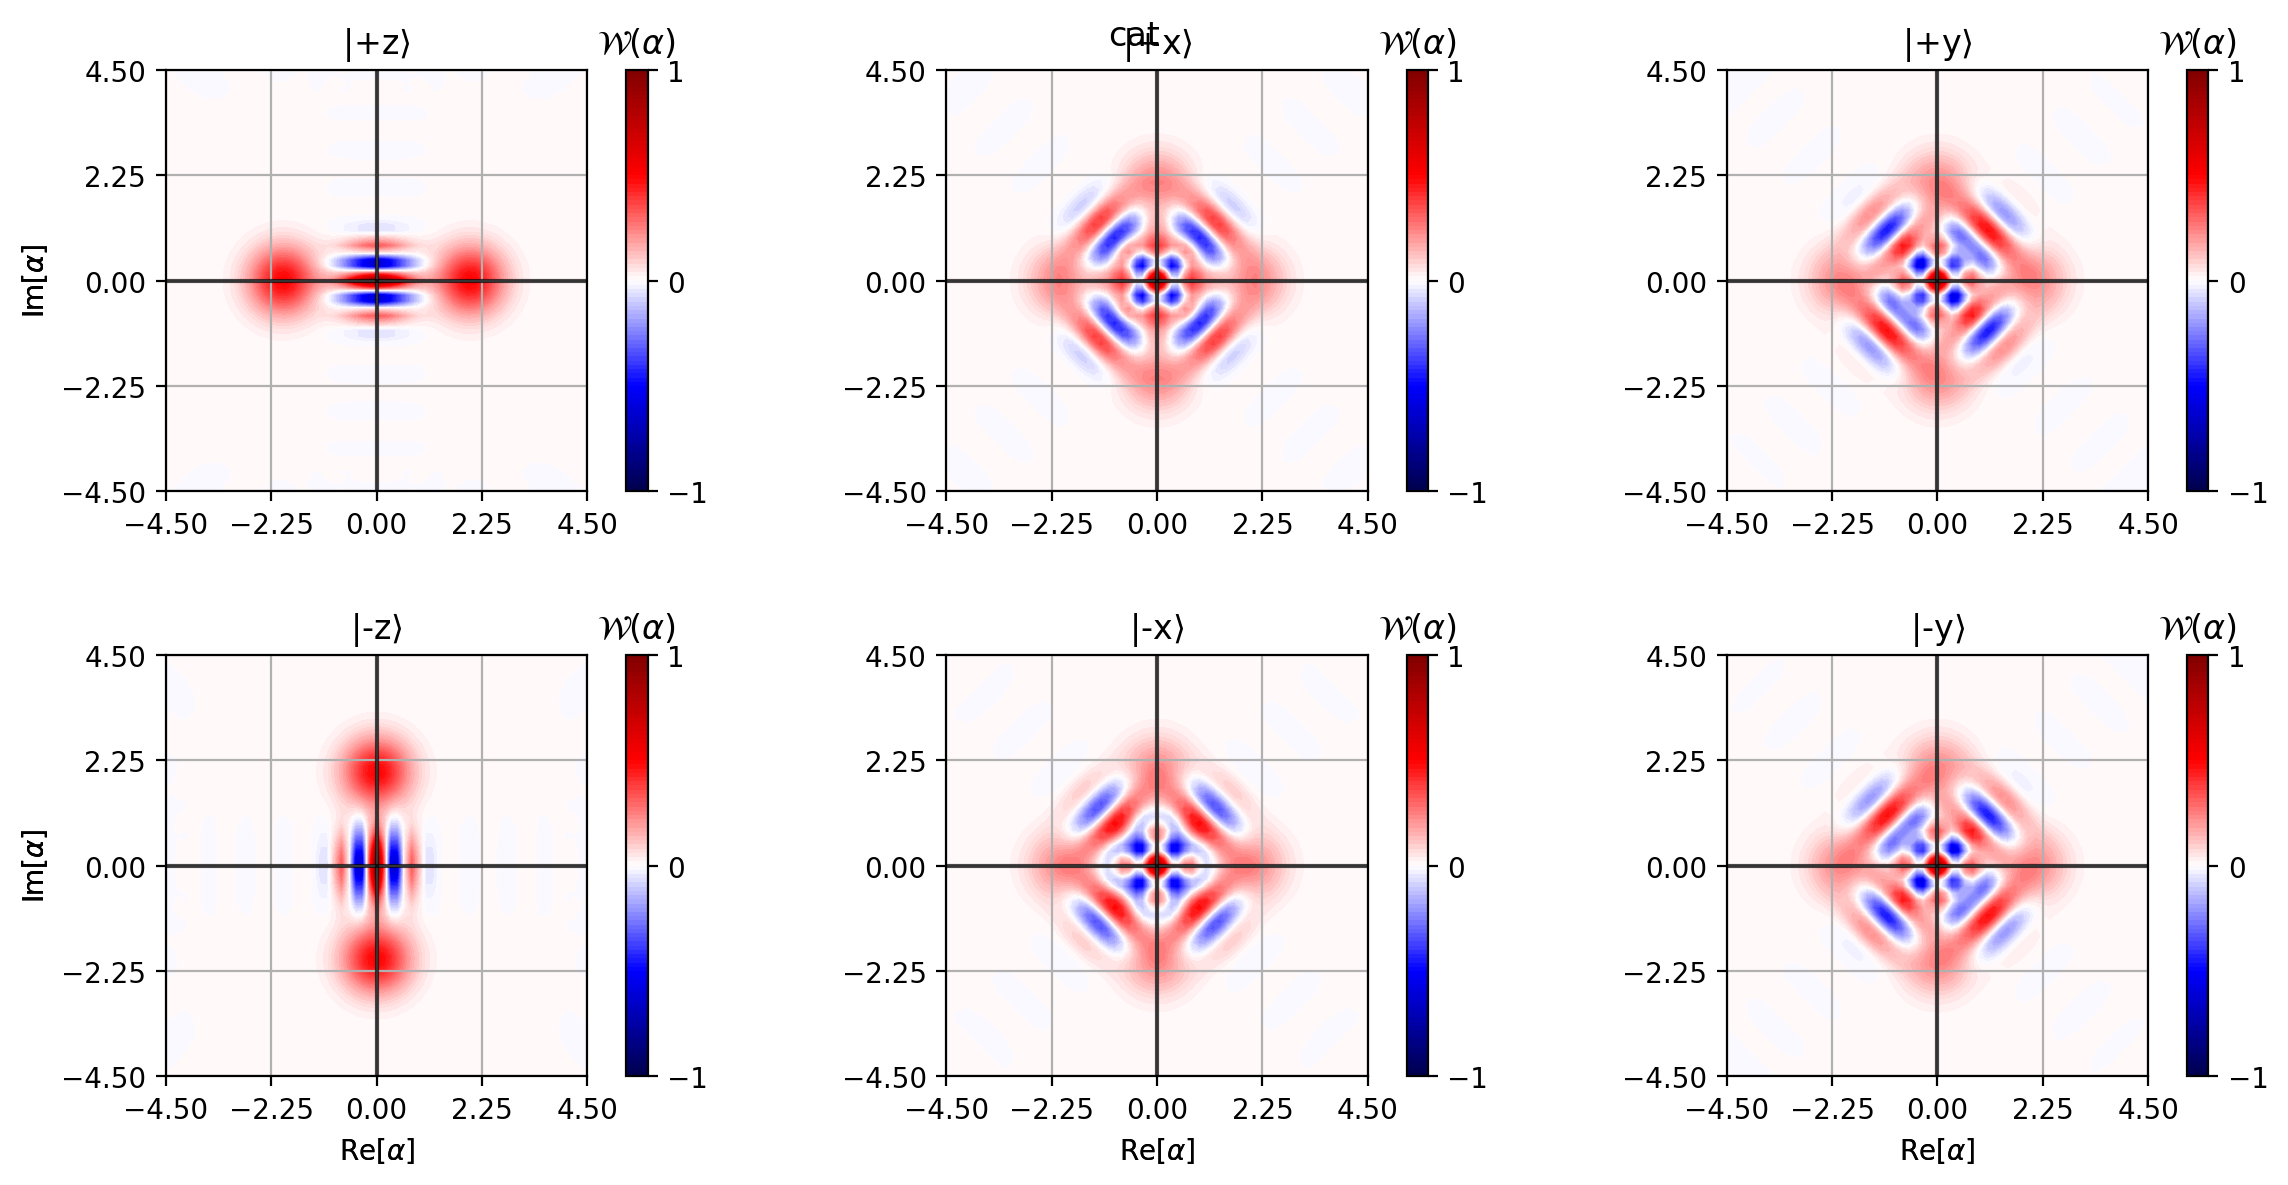

In [5]:
# Plot all 6 logical basis states as Wigner functions
cat.plot_code_states(qp_type=jqt.WIGNER)
plt.show()

In [6]:
# Logical Pauli operators in the oscillator Hilbert space
print("x_U shape:", cat.x_U.data.shape)  # N×N unitary
print("z_U shape:", cat.z_U.data.shape)

# Verify: X|+z⟩ = |-z⟩  (logical bit flip)
flipped = cat.x_U @ cat.basis["+z"]
overlap = float(jnp.abs(jqt.overlap(flipped, cat.basis["-z"])))
print(f"\n|⟨-z| X_L |+z⟩| = {overlap:.6f}  (should be 1.0)")

x_U shape: (40, 40)
z_U shape: (40, 40)

|⟨-z| X_L |+z⟩| = 1.000000  (should be 1.0)


## 2. GKP Qubit

The GKP code encodes logical $|0\\rangle$ and $|1\\rangle$ as superpositions of equally-spaced coherent states on a square lattice in phase space, stabilised by displacement operators:
$$S_x = e^{i2\\sqrt{\\pi}\\hat{x}}, \\quad S_p = e^{-i2\\sqrt{\\pi}\\hat{p}}.$$

Physical GKP states are **finite-energy** approximations controlled by $\\delta$: smaller $\\delta$ → better approximation but more squeezing required.

In [7]:
gkp = jqtb.SquareGKPQubit({"N": 60, "delta": 0.3})

print(f"Squeezing required: {float(gkp.params['squeezing_dB']):.1f} dB")
print(f"Available gates:   {list(gkp.common_gates.keys())}")

Squeezing required: 10.5 dB
Available gates:   ['a_dag', 'a', 'x', 'p', 'E', 'E_inv', 'X_0', 'Z_0', 'Y_0', 'X', 'Z', 'Y', 'Z_s_0', 'S_x_0', 'S_z_0', 'S_y_0']


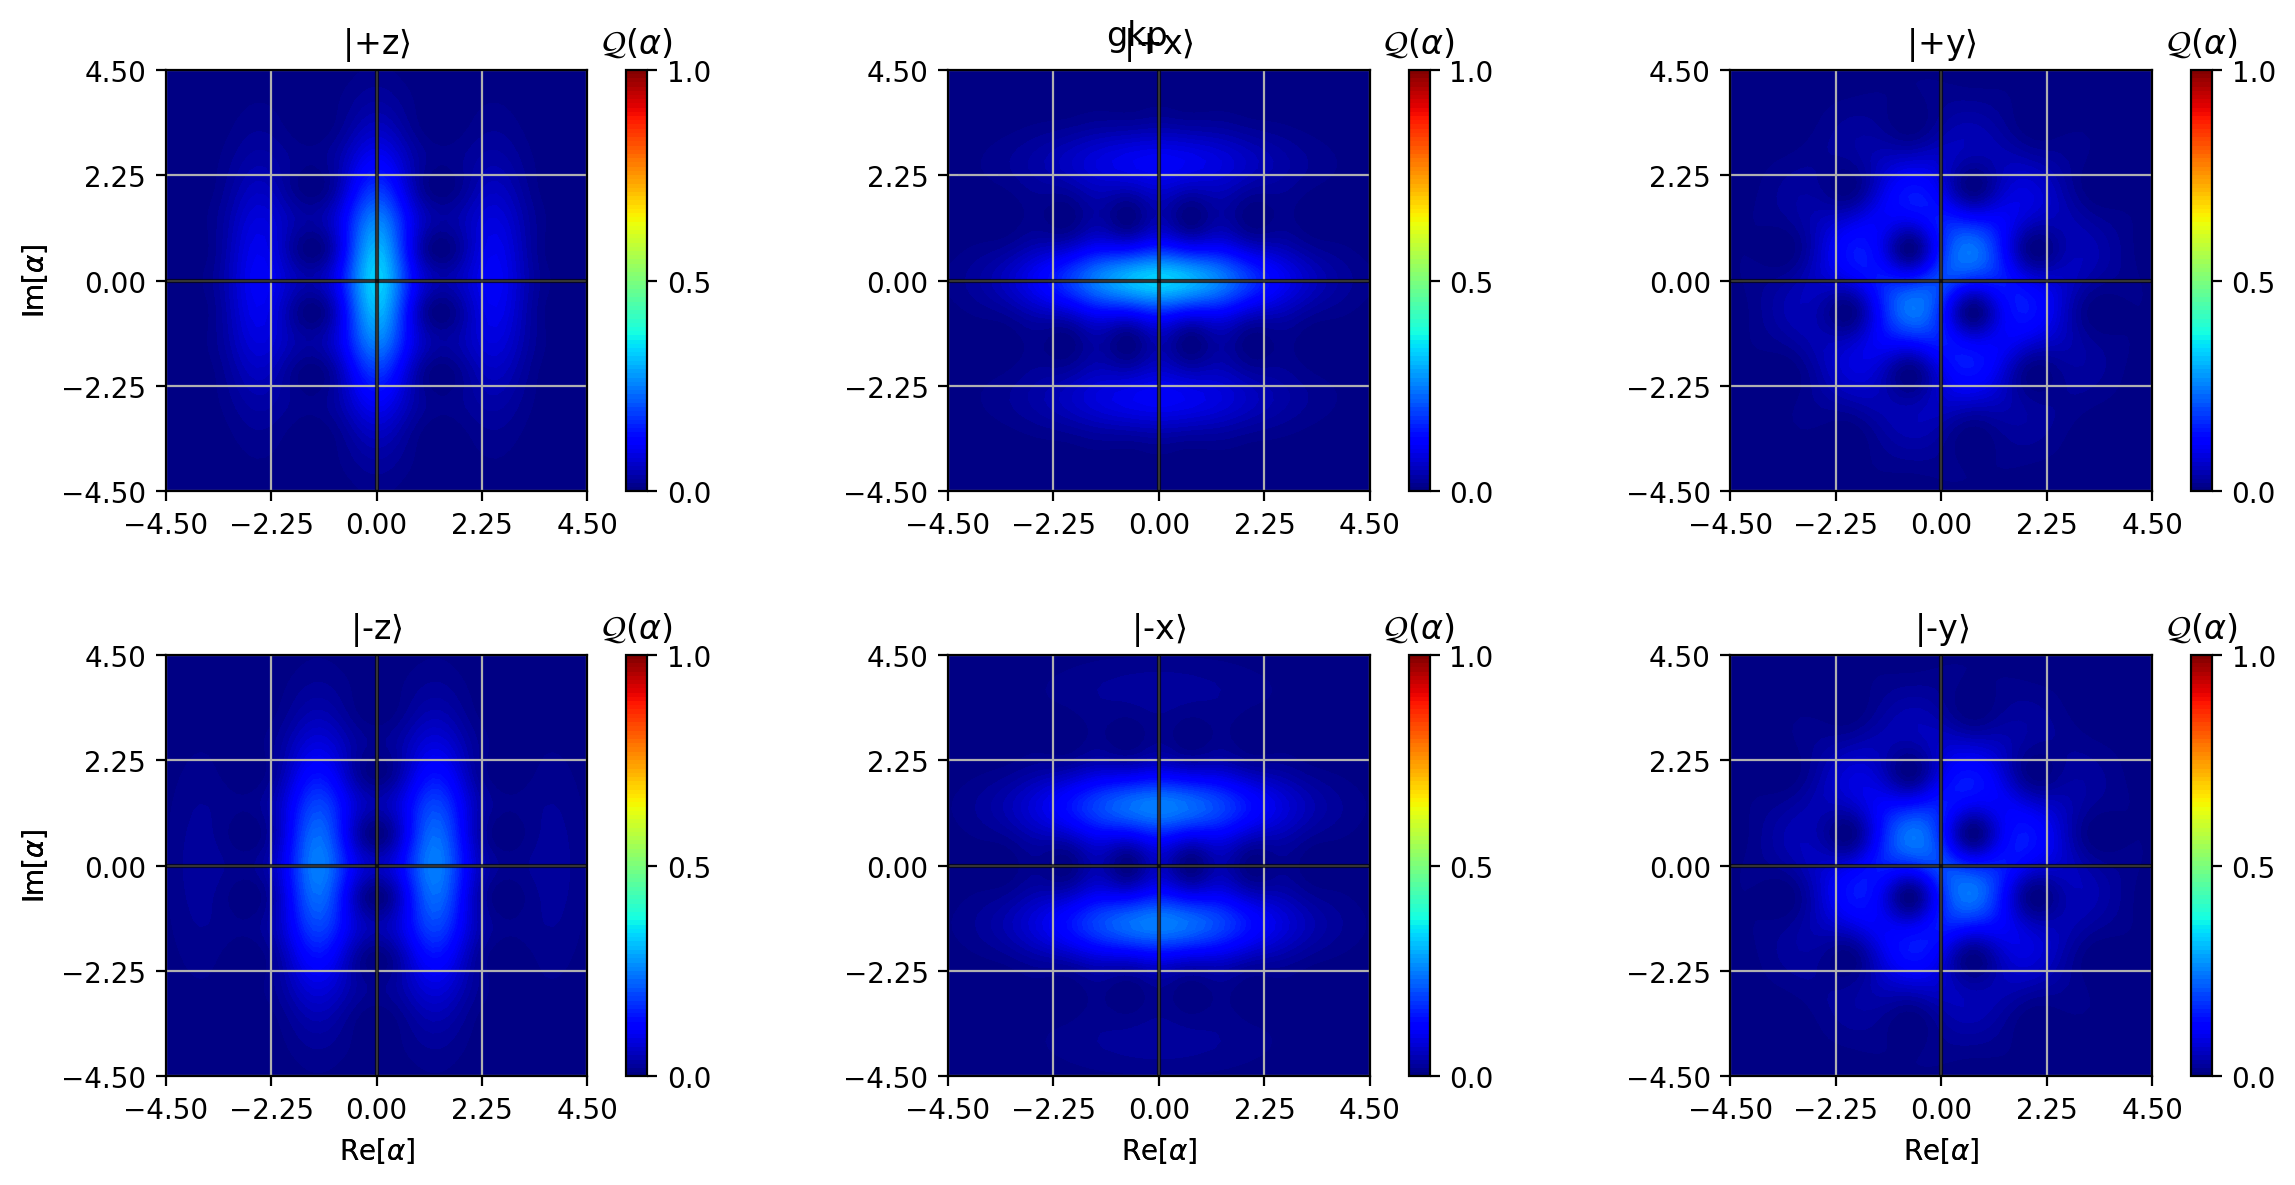

In [8]:
# GKP codewords look like a grid of Gaussian peaks — best seen in the Husimi Q-function
gkp.plot_code_states(qp_type=jqt.HUSIMI)
plt.show()

In [9]:
# Logical gates for GKP are displacement operators in phase space
# X_L = D(sqrt(π)), Z_L = D(i*sqrt(π))
X_L = gkp.x_U
Z_L = gkp.z_U

# Verify: X_L|+z⟩ → |-z⟩
flipped_gkp = X_L @ gkp.basis["+z"]
overlap_gkp = float(jnp.abs(jqt.overlap(flipped_gkp, gkp.basis["-z"])))
print(f"|⟨-z| X_L |+z⟩| = {overlap_gkp:.4f}  (≈ 1 for small δ)")

|⟨-z| X_L |+z⟩| = 0.9988  (≈ 1 for small δ)


## 3. Binomial Qubit

Binomial codes use superpositions of Fock states whose photon-number spacings are designed to be transparent to specific error channels. The parameters $(L, G, D)$ set the orders of loss, gain, and dephasing errors that are correctable:

$$|{+z}\rangle = \sum_{m=0,2,\ldots} \sqrt{\binom{S+1}{m}} |m(S+1)\rangle, \quad S = L + G.$$

Parameters: {'N': 30, 'L': Array(1, dtype=int64, weak_type=True), 'G': Array(0, dtype=int64, weak_type=True), 'D': Array(0, dtype=int64, weak_type=True)}


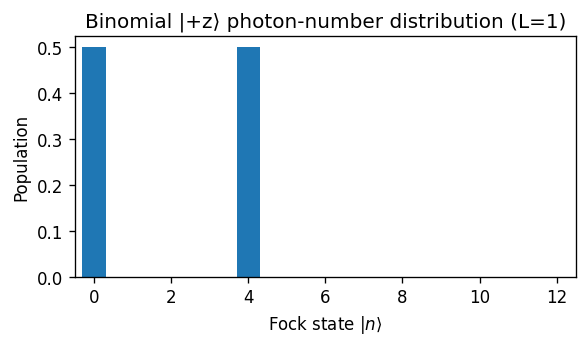

In [10]:
# L=1, G=0, D=0: protect against single-photon loss
binomial = jqtb.BinomialQubit({"N": 30, "L": 1, "G": 0, "D": 0})

print("Parameters:", binomial.params)

# Photon number distribution of |+z⟩
psi = binomial.basis["+z"]
probs = jnp.abs(psi.data.flatten()) ** 2

fig, ax = plt.subplots(figsize=(5, 3), dpi=120)
ax.bar(range(len(probs)), probs, width=0.6)
ax.set_xlabel("Fock state $|n\\rangle$")
ax.set_ylabel("Population")
ax.set_title("Binomial |+z⟩ photon-number distribution (L=1)")
ax.set_xlim(-0.5, 12.5)
fig.tight_layout()
plt.show()

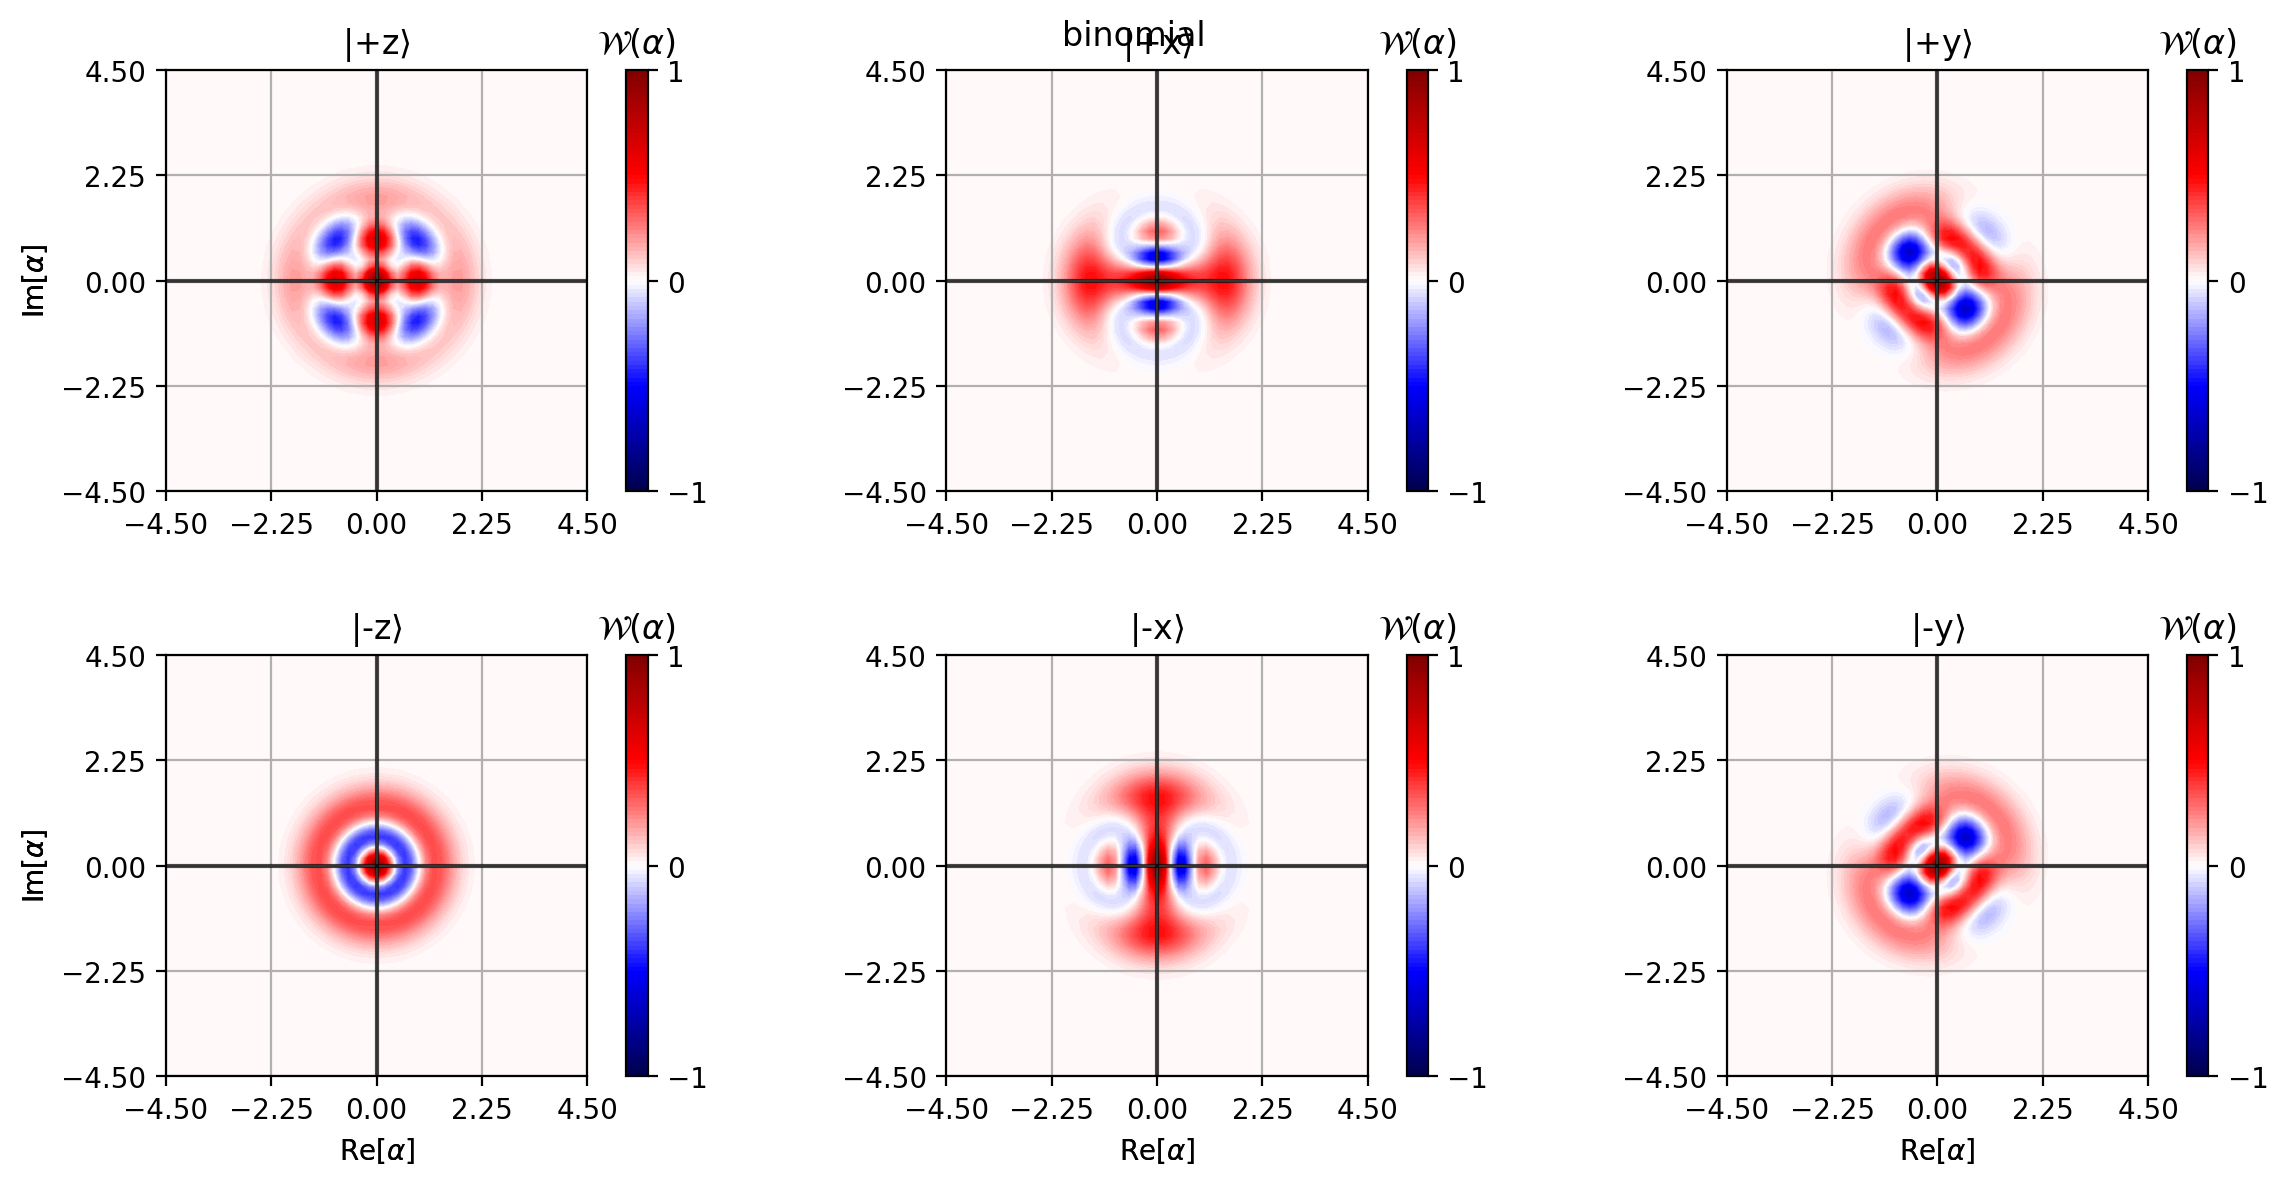

In [11]:
# Wigner functions of all 6 basis states
binomial.plot_code_states(qp_type=jqt.WIGNER)
plt.show()

## 4. Batched Wigner Visualization

jaxquantum's `Qarray` supports batch dimensions (`bdim`) so you can visualize a sweep of states in a single `plot_wigner` call. Here we sweep the cat amplitude $\alpha$ and see how the Wigner interference fringes grow.

Batch state shape: (4, 40, 1)


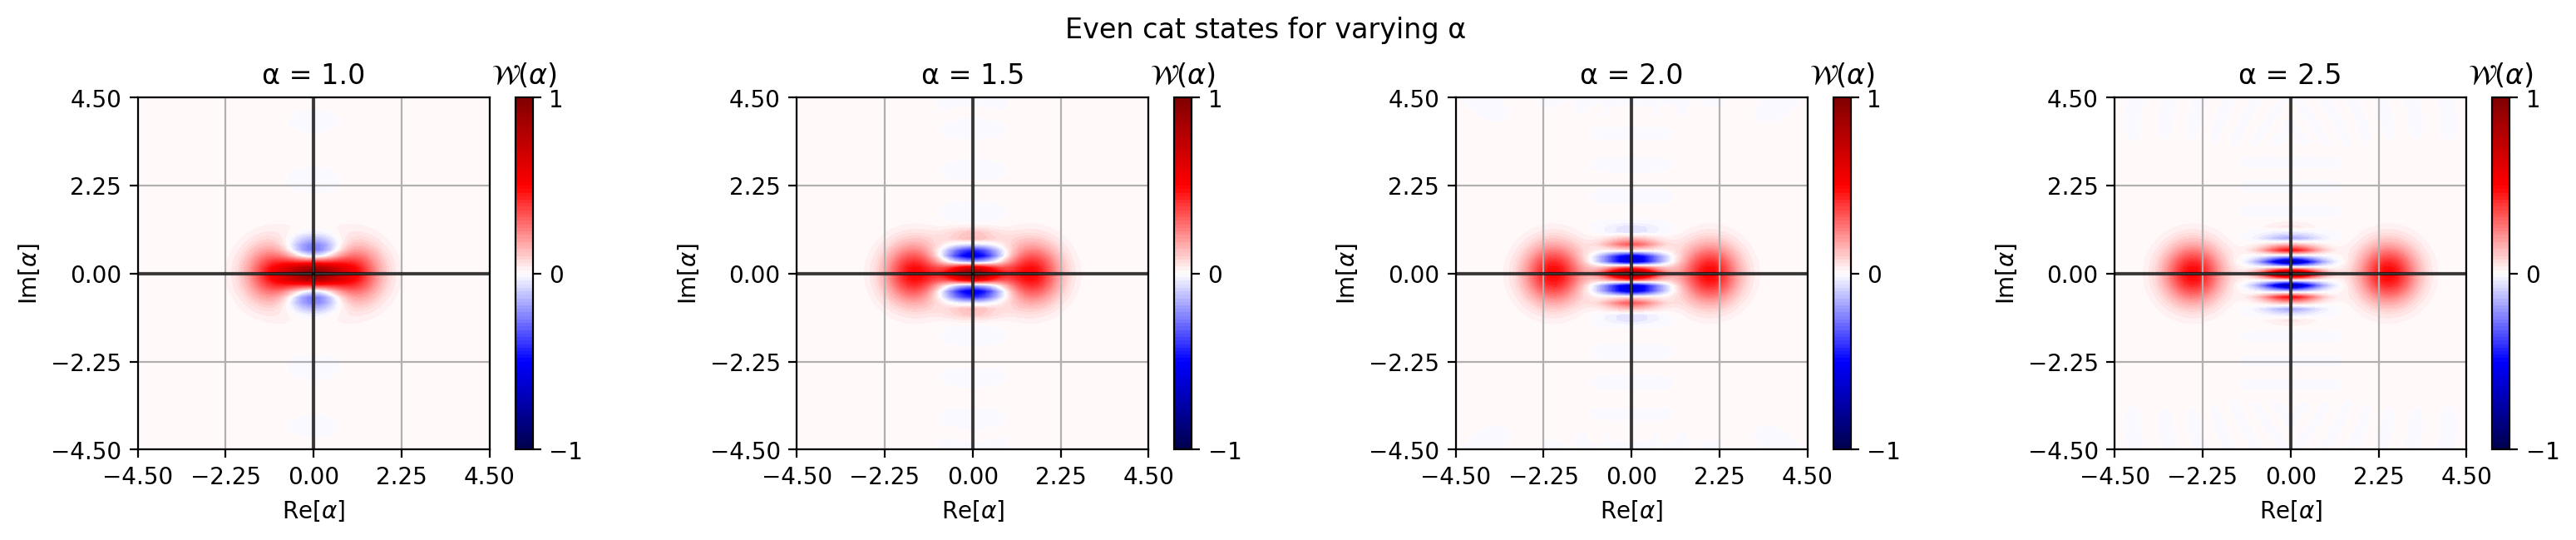

In [12]:
N = 40
alphas = jnp.array([1.0, 1.5, 2.0, 2.5])

# Build a batch of even cat states |α⟩ + |-α⟩ using displacement operators
# displace(N, alphas) returns a batched Qarray when alphas is an array
D_pos = jqt.displace(N, alphas)
D_neg = jqt.displace(N, -alphas)
vac = jqt.basis(N, 0)

# Each element: |α⟩ + |-α⟩, then normalise
cat_states = D_pos @ vac + D_neg @ vac
cat_states = jqt.unit(cat_states)  # normalise batch

print("Batch state shape:", cat_states.data.shape)  # (4, N, 1)

xvec = jnp.linspace(-4.5, 4.5, 61)
jqt.plot_wigner(
    cat_states, xvec, xvec,
    subtitles=np.array([f"α = {a}" for a in alphas]),
    figtitle="Even cat states for varying α",
)
plt.show()

## 5. Logical Gate Verification & Dynamics

Logical gates should act within the code space. We verify this by checking overlaps and by simulating the effect of photon loss on a cat codeword.

In [13]:
# --- Pauli algebra check ---
# X² = I on the code space: X_L X_L |+z⟩ = |+z⟩
cat = jqtb.CatQubit({"N": 40, "alpha": 2.0})

state_after_XX = cat.x_U @ (cat.x_U @ cat.basis["+z"])
overlap_XX = float(jnp.abs(jqt.overlap(state_after_XX, cat.basis["+z"])))
print(f"|⟨+z| X² |+z⟩| = {overlap_XX:.6f}  (should be 1.0)")

# XZ = -ZX (anti-commutation) on code states: ZX|+z⟩ = -XZ|+z⟩
xz_state = cat.x_U @ (cat.z_U @ cat.basis["+z"])
zx_state = cat.z_U @ (cat.x_U @ cat.basis["+z"])
overlap_anticommute = float(jnp.real(jqt.overlap(xz_state, zx_state)))
print(f"⟨XZ|ZX⟩ = {overlap_anticommute:.6f}  (should be -1.0 — Pauli anti-commutation)")

|⟨+z| X² |+z⟩| = 1.000000  (should be 1.0)
⟨XZ|ZX⟩ = 0.998854  (should be -1.0 — Pauli anti-commutation)


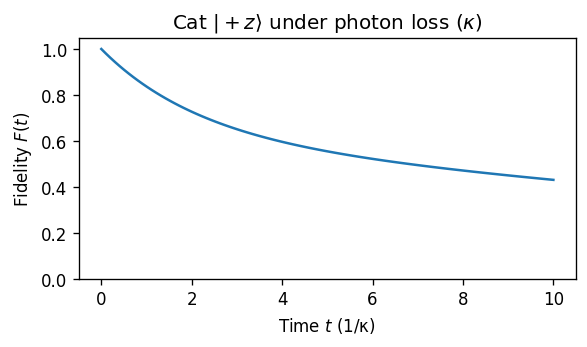

In [14]:
# --- Photon loss simulation ---
# Simulate |+z⟩ evolving under single-photon loss (κ) and track
# the fidelity with the initial state: F(t) = ⟨+z|ρ(t)|+z⟩

N    = 40
kappa = 0.05   # photon loss rate
cat   = jqtb.CatQubit({"N": N, "alpha": 2.0})

H     = jqt.num(N) * 0.0    # no free evolution; pure loss
c_ops = jqt.Qarray.from_list([jnp.sqrt(kappa) * jqt.destroy(N)])
rho0  = jqt.ket2dm(cat.basis["+z"])
tlist = jnp.linspace(0.0, 10.0, 100)

result = jqt.mesolve(
    H, rho0, tlist,
    c_ops=c_ops,
    solver_options=jqt.SolverOptions.create(progress_meter=False),
)

psi_pz = cat.basis["+z"]
fidelity = jnp.real(jqt.tr(jqt.ket2dm(psi_pz) @ result))

fig, ax = plt.subplots(figsize=(5, 3), dpi=120)
ax.plot(tlist, fidelity)
ax.set_xlabel("Time $t$ (1/κ)")
ax.set_ylabel(r"Fidelity $F(t)$")
ax.set_title(r"Cat $|+z\rangle$ under photon loss ($\kappa$)")
ax.set_ylim(0, 1.05)
fig.tight_layout()
plt.show()

## What's Next?

- Build circuits with bosonic gates (conditional displacement, ECD): see the [Circuits tutorial](circuits.html).
- Use sparse operators to scale to larger Hilbert spaces (e.g. GKP with $N=200$): see [Sparse Backends](sparse_backends.html).
- Couple a bosonic mode to a transmon for realistic qubit-oscillator systems: see [Devices & Systems](devices.html).